In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from utils.constants import CLASS_LABEL
from utils.definitions import RAW_LABELS_DIR

count    596.000000
mean       3.013423
std        2.039069
min        1.000000
25%        2.000000
50%        2.000000
75%        4.000000
max       11.000000
Name: labels, dtype: float64
labels
1     145
2     187
3      74
4      66
5      35
6      46
7      21
8      11
9       6
10      4
11      1
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596 entries, 0 to 595
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   file    596 non-null    object
 1   labels  596 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 9.4+ KB
None


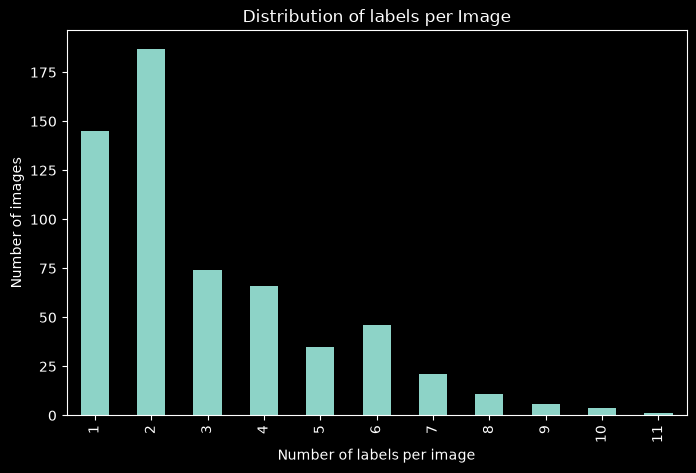

labels
11    1
Name: count, dtype: int64


In [11]:
label_counts = {}

for file in RAW_LABELS_DIR.glob("*.txt"):
    with open(file) as f:
        label_counts[file.stem] = sum(1 for line in f if line.split() and line.split()[0] == CLASS_LABEL)

df = pd.DataFrame(list(label_counts.items()), columns=['file', 'labels'])

# Basic statistics
print(df['labels'].describe())

# Count amount of each label
print(df['labels'].value_counts().sort_index())

print(df.info())

# Plot distribution of label amounts
plt.figure(figsize=(8,5))
df["labels"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Number of labels per image")
plt.ylabel("Number of images")
plt.title("Distribution of labels per Image")
plt.show()

# Values with fewer than 2 samples cannot be stratified
rare_counts = df["labels"].value_counts()
print(rare_counts[rare_counts < 2])
